# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (mean_squared_error, r2_score,mean_absolute_error
                             ,accuracy_score, precision_score, recall_score)
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Открытие датасета

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv("Airline Quality Ratings.csv")
df=df.dropna()
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [39]:
df.info()
df=df.drop('ID',axis=1)

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129487 non-null  int64  
 1   Gender                                  129487 non-null  object 
 2   Age                                     129487 non-null  int64  
 3   Customer Type                           129487 non-null  object 
 4   Type of Travel                          129487 non-null  object 
 5   Class                                   129487 non-null  object 
 6   Flight Distance                         129487 non-null  int64  
 7   Departure Delay                         129487 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129487 non-null  int64  
 10  Ease of Online Booking                  129487 no

In [9]:
df['Arrival Delay']

0          5.0
1         39.0
2          0.0
3          0.0
4          1.0
          ... 
129875     3.0
129876     0.0
129877    14.0
129878    22.0
129879     0.0
Name: Arrival Delay, Length: 129487, dtype: float64

In [7]:
df.Satisfaction.value_counts()

Satisfaction
Neutral or Dissatisfied    73225
Satisfied                  56262
Name: count, dtype: int64

In [59]:
len(df)

129487

<Axes: xlabel='Satisfaction'>

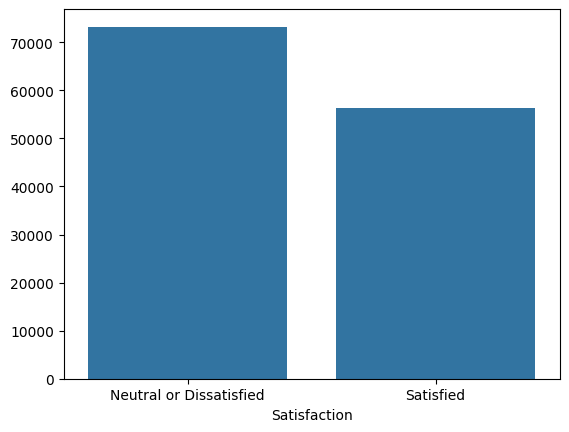

In [8]:
sns.barplot(x = df.Satisfaction.value_counts().index, y = df.Satisfaction.value_counts().values)

In [14]:
df.Class.value_counts()

Class
Business        61990
Economy         58117
Economy Plus     9380
Name: count, dtype: int64

In [4]:
df['Customer Type'] = df['Customer Type'].map({'First-time': 0, 'Returning': 1})
df['Type of Travel'] = df['Type of Travel'].map({'Business': 0, 'Personal': 1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df=pd.get_dummies(data=df,columns=['Class'], drop_first=True,dtype=int)   

In [41]:
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129487 non-null  int64  
 1   Age                                     129487 non-null  int64  
 2   Customer Type                           129487 non-null  int64  
 3   Type of Travel                          129487 non-null  int64  
 4   Flight Distance                         129487 non-null  int64  
 5   Departure Delay                         129487 non-null  int64  
 6   Arrival Delay                           129487 non-null  float64
 7   Departure and Arrival Time Convenience  129487 non-null  int64  
 8   Ease of Online Booking                  129487 non-null  int64  
 9   Check-in Service                        129487 non-null  int64  
 10  Online Boarding                         129487 no

In [5]:
df['Satisfaction']

0         Neutral or Dissatisfied
1                       Satisfied
2                       Satisfied
3                       Satisfied
4                       Satisfied
                   ...           
129875    Neutral or Dissatisfied
129876    Neutral or Dissatisfied
129877    Neutral or Dissatisfied
129878                  Satisfied
129879    Neutral or Dissatisfied
Name: Satisfaction, Length: 129487, dtype: object

In [6]:
df['Satisfaction'] = df['Satisfaction'].map({'Neutral or Dissatisfied': 0, 'Satisfied': 1})

In [44]:
df['Satisfaction']

0         0
1         1
2         1
3         1
4         1
         ..
129875    0
129876    0
129877    0
129878    1
129879    0
Name: Satisfaction, Length: 129487, dtype: int64

In [45]:
df.head()

,Gender,Age,Customer Type,Type of Travel,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,...,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Class_Economy,Class_Economy Plus
0,0,48,0,0,821,2,5.0,3,3,4,...,2,5,5,5,3,5,5,0,0,0
1,1,35,1,0,821,26,39.0,2,2,3,...,5,5,3,5,2,5,5,1,0,0
2,0,41,1,0,853,0,0.0,4,4,4,...,3,5,5,3,4,3,3,1,0,0
3,0,50,1,0,1905,0,0.0,2,2,3,...,5,4,4,5,2,5,5,1,0,0
4,1,49,1,0,3470,0,1.0,3,3,3,...,4,5,4,3,3,3,3,1,0,0


<Axes: >

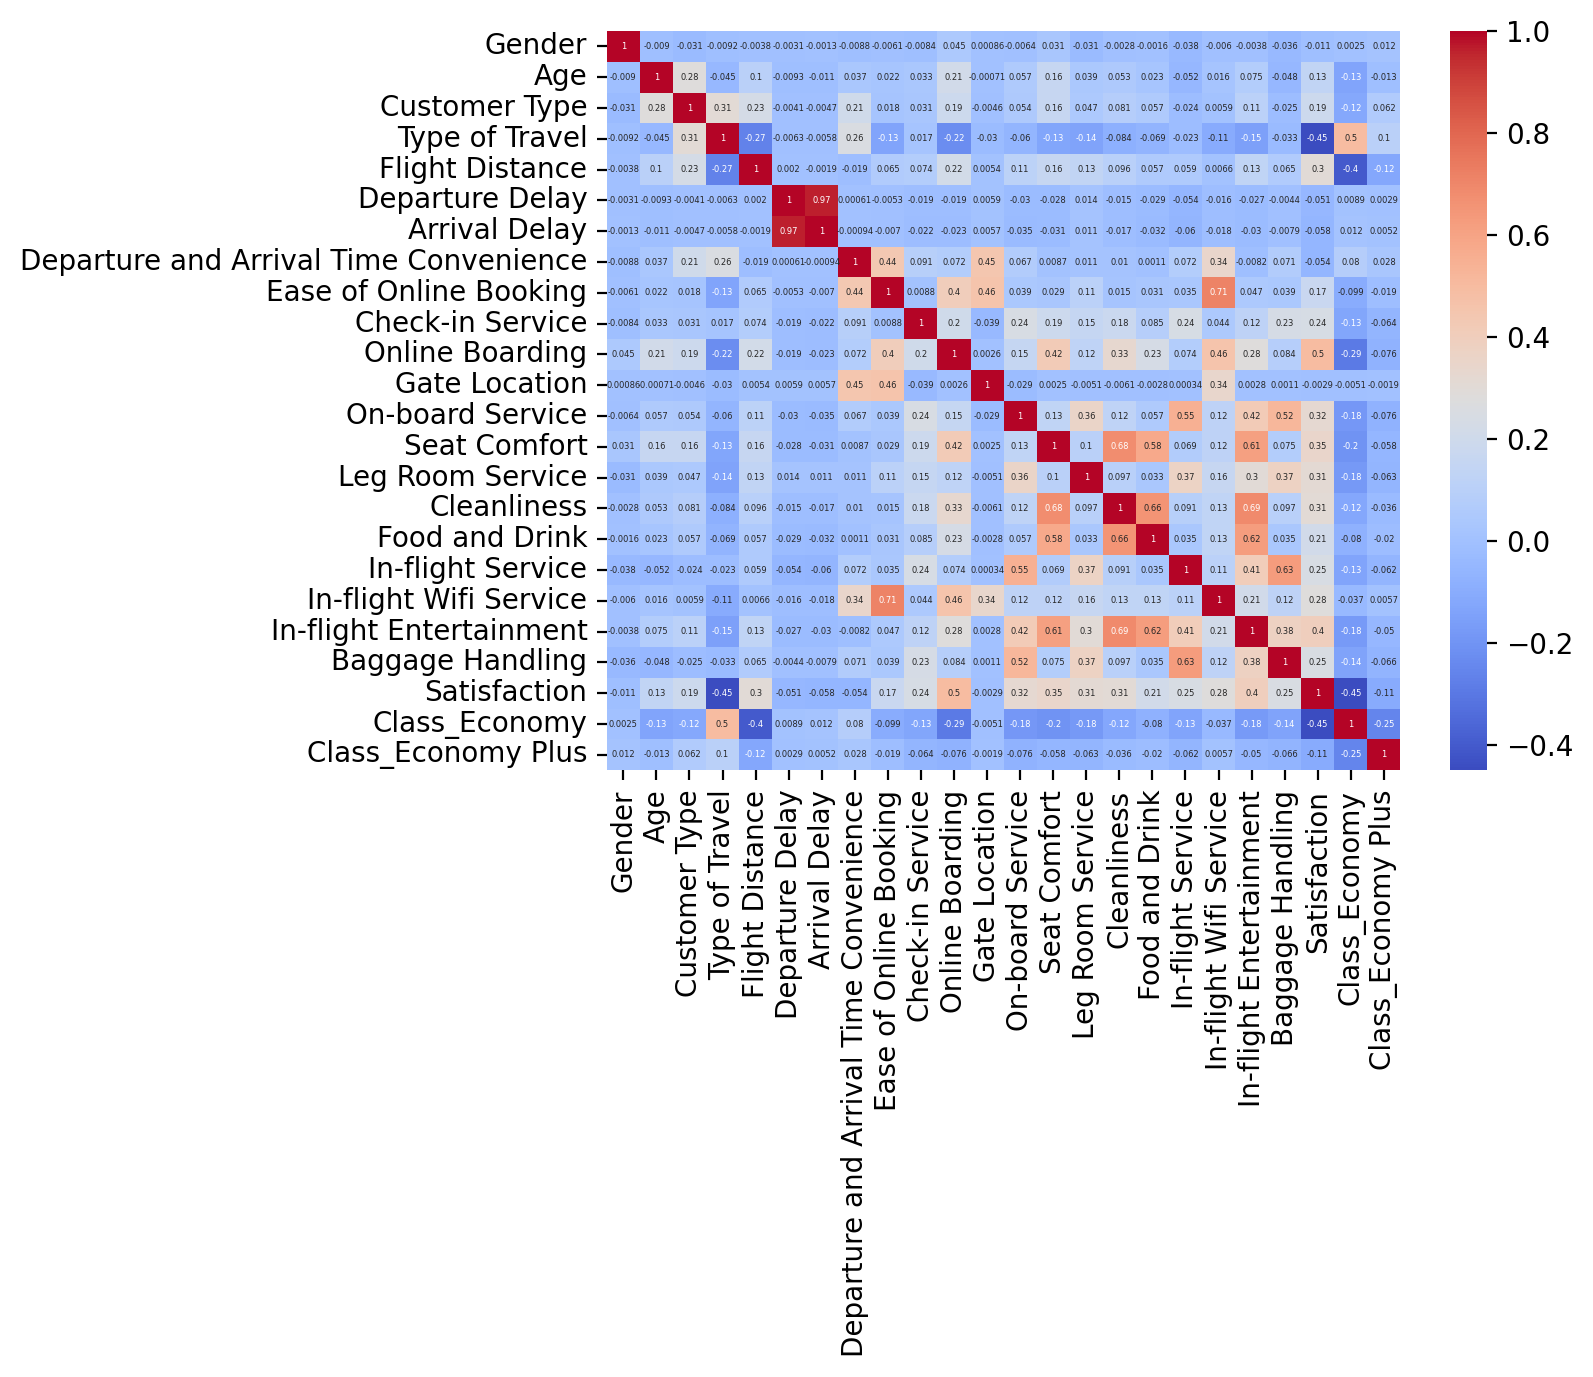

In [46]:
plt.figure(dpi=200)
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',annot_kws={'size':3}) 

<Axes: xlabel='Satisfaction', ylabel='Count'>

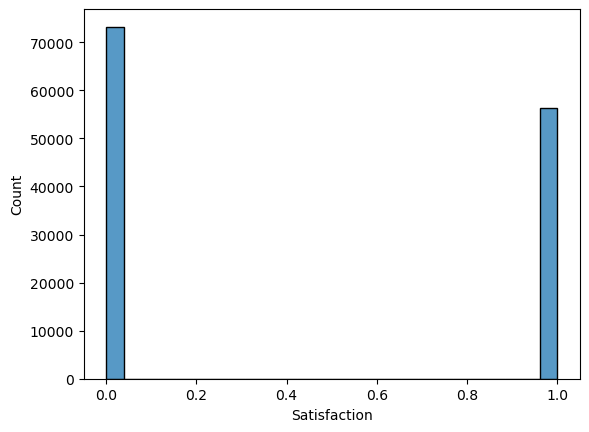

In [47]:
sns.histplot(df['Satisfaction'])

In [18]:
range(0,df.shape[0])

range(0, 129487)

In [ ]:
# доли классов
print((df['Satisfaction']==1).mean())
print((df['Satisfaction']==0).mean())

0.43449921613752734
0.5655007838624727


In [17]:
df.head(10)

,ID,Gender,Age,Customer Type,Type of Travel,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Class_Economy,Class_Economy Plus
0,1,0,48,0,0,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied,0,0
1,2,1,35,1,0,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied,0,0
2,3,0,41,1,0,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied,0,0
3,4,0,50,1,0,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied,0,0
4,5,1,49,1,0,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied,0,0
5,6,0,43,1,0,3788,0,0.0,4,4,3,5,4,4,4,4,3,3,4,4,4,4,Satisfied,0,0
6,7,0,43,1,0,1963,0,0.0,3,3,4,4,3,5,5,5,4,5,5,3,5,5,Satisfied,0,0
7,8,1,60,1,0,853,0,3.0,3,4,3,4,4,3,4,4,4,4,3,4,3,3,Satisfied,0,0
8,9,0,50,1,0,2607,0,0.0,1,1,3,2,1,4,3,4,3,3,4,4,4,4,Neutral or Dissatisfied,0,0
9,10,1,38,1,0,2822,13,0.0,2,5,3,5,2,5,4,5,4,2,5,2,5,5,Satisfied,0,0


## Перевод Satisfaction в непрерывную оценку. Способ_1

In [10]:
# Вычисляем корреляцию всех числовых признаков с целевой переменной 'Satisfaction'
# numeric_only=True — учитываем только числовые столбцы
# Результат — Series, где индекс = название признака, значение = коэффициент корреляции
# Сортируем по убыванию (наиболее положительно коррелирующие — сверху)
correlation_with_target = df.corr(numeric_only=True)['Satisfaction'].sort_values(ascending=False)

# Берём 10 самых коррелирующих признаков, НО пропускаем первый!
# Почему? Потому что первый — это сама 'Satisfaction' (корреляция с собой = 1.0)
# Поэтому [1:11] — от второго до одиннадцатого (10 признаков без целевой переменной)
top_correlated = correlation_with_target[1:11]

def correlation_based_conversion(row, satisfaction_value, top_features, correlations):
    """
    Преобразует строку данных (row) в оценку удовлетворённости на основе корреляций.
    
    Параметры:
    - row: одна строка датафрейма (pandas Series)
    - satisfaction_value: исходное значение 'Satisfaction' (0 или 1)
    - top_features: Series с топ-признаками (индекс = название признака)
    - correlations: Series с корреляциями этих признаков с 'Satisfaction'
    """
    
    # Используем квадрат корреляции как меру "важности" признака (R²-подобный вес)
    # Это подчёркивает сильные связи и ослабляет слабые
    abs_correlations = correlations**2
    
    # Нормализуем квадраты корреляций в веса (сумма весов = 1)
    weights = abs_correlations / abs_correlations.sum()
    
    # Вычисляем взвешенную сумму значений признаков из top_features
    weighted_score = 0
    for feature in top_features.index:
        weighted_score += row[feature] * weights[feature]
    
    # Минимально и максимально возможные значения взвешенной суммы,
    # если все признаки принимают значения от 1 до 5 (предположение о шкале)
    min_possible = sum(1 * weights)   # все признаки = 1
    max_possible = sum(5 * weights)   # все признаки = 5
    
    # Нормализуем weighted_score в диапазон [1, 5]
    normalized_score = 1 + (weighted_score - min_possible) / (max_possible - min_possible) * 5
    
    # В зависимости от исходного Satisfaction (0 или 1),
    # задаём диапазон для случайной компоненты:
    if satisfaction_value == 0:  
        base_range_min = 1.0
        base_range_max = 3.0   # "неудовлетворённые" — оценка в нижней половине
    else:  
        base_range_min = 3.01  
        base_range_max = 5.0   # "удовлетворённые" — оценка в верхней половине
    
    # Финальная оценка — 75% от нормализованного скоринга + 25% случайной величины из нужного диапазона
    final_score = (normalized_score * 0.75) + (np.random.uniform(base_range_min, base_range_max) * 0.25)
    
    # Ограничиваем итоговое значение в пределах [1.0, 5.0] и округляем до 2 знаков
    return max(1.0, min(5.0, round(final_score, 2)))

# Выбираем ТОП-6 признаков из ранее отобранных 10 (top_correlated)
# Это признаки, наиболее сильно коррелирующие с 'Satisfaction'
top_features = top_correlated.head(6)

# Применяем функцию correlation_based_conversion к каждой строке датафрейма
# Для каждой строки передаём:
# - саму строку (row)
# - значение Satisfaction в этой строке
# - топ-6 признаков
# - полные корреляции (для расчёта весов)
df['Satisfaction_Score_Correlation'] = df.apply(
    lambda row: correlation_based_conversion(row, row['Satisfaction'], top_features, top_correlated), 
    axis=1  # axis=1 — применяем по строкам
)

In [11]:
correlation_with_target = df.corr(numeric_only=True)['Satisfaction'].sort_values(ascending=False)

top_correlated = correlation_with_target[1:11]  


def correlation_based_conversion(row, satisfaction_value, top_features, correlations):

    abs_correlations = correlations**2
    weights = abs_correlations / abs_correlations.sum()
    
    weighted_score = 0
    for feature in top_features.index:
        weighted_score += row[feature] * weights[feature]
    
    
    min_possible = sum(1 * weights)  
    max_possible = sum(5 * weights)  
    
    normalized_score = 1 + (weighted_score - min_possible) / (max_possible - min_possible) * 5
    
    if satisfaction_value == 0:  
        base_range_min = 1.0
        base_range_max = 3.0

    else:  
        # base_range_min = 3.01 
        base_range_min = 3.5
 
        base_range_max = 5.0
    
    final_score = (normalized_score * 0.75) + (np.random.uniform(base_range_min, base_range_max) * 0.25)
    
    return max(1.0, min(5.0, round(final_score, 2)))


top_features = top_correlated.head(6)  

df['Satisfaction_Score_Correlation'] = df.apply(
    lambda row: correlation_based_conversion(row, row['Satisfaction'], top_features, top_correlated), 
    axis=1
)

Text(0.5, 0.98, 'Распределение Y')

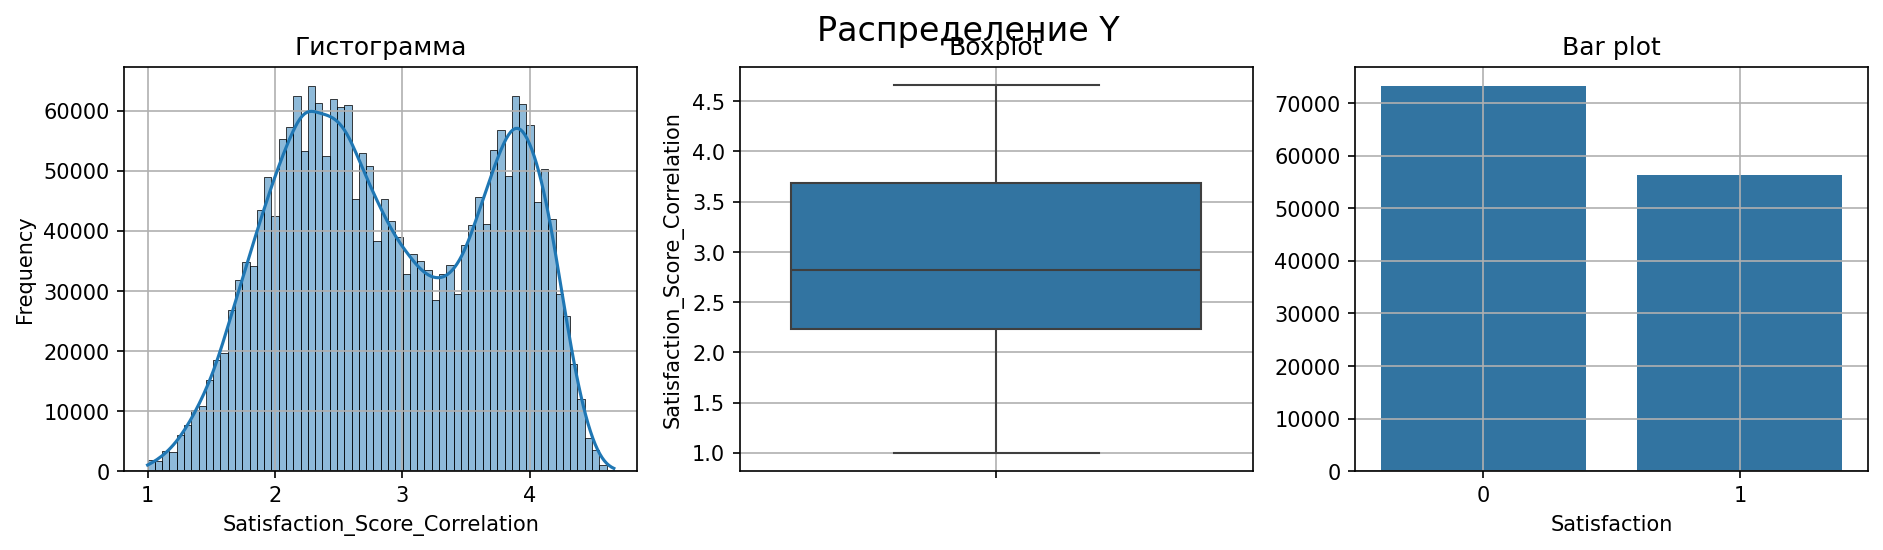

In [27]:
fig, axes = plt.subplots(1,3 ,figsize=(15, 3.5), dpi=150)

sns.histplot(df,x='Satisfaction_Score_Correlation',stat="frequency",kde=True,ax=axes[0])
axes[0].set_title('Гистограмма')
axes[0].grid(True)


sns.boxplot(df['Satisfaction_Score_Correlation'],ax=axes[1])
axes[1].set_title('Boxplot')
axes[1].grid(True)

sns.barplot(x = df.Satisfaction.value_counts().index, y = df.Satisfaction.value_counts().values, ax=axes[2])
axes[2].set_title('Bar plot')
axes[2].grid(True)

fig.suptitle('Распределение Y', fontsize=16)


## Перевод Satisfaction в непрерывную оценку. Способ 2

In [7]:
# список столбцов в которых поставлена оценка
score_columns = ['Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling']

In [8]:
# средняя оценка поставленная пасажирами по столбцам
df['avg_score'] = df[score_columns].mean(axis=1).round(3)

<Axes: xlabel='avg_score', ylabel='Satisfaction_Score_Correlation'>

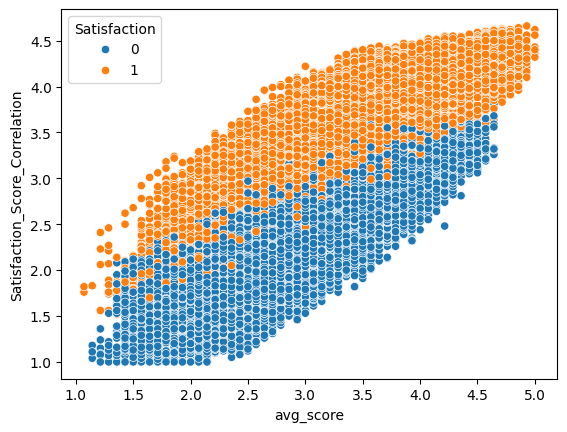

In [13]:
# кросс-плот. средней оценка vs Satisfaction_Score_Correlation
sns.scatterplot(df, x = 'avg_score', y='Satisfaction_Score_Correlation', hue = 'Satisfaction')

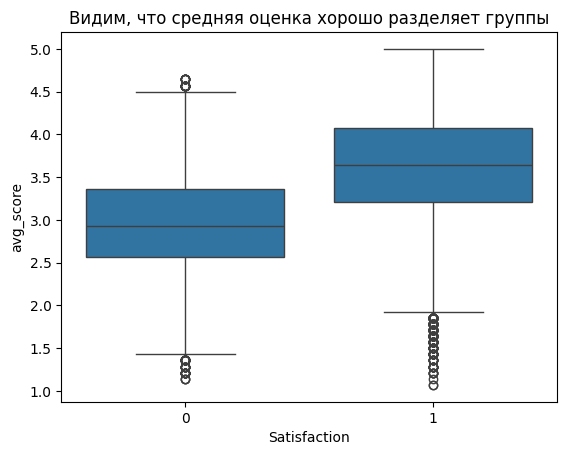

In [26]:
ax = sns.boxplot(data=df, x='Satisfaction', y='avg_score')
ax.set_title('Видим, что средняя оценка хорошо разделяет группы')
plt.show()

### Различные функции принадлежности на выбор

In [ ]:
def trimf(x, a, b, c):
    """Треугольная функция принадлежности"""
    return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

def trapmf(x, a, b, c, d):
    """Трапециевидная функция принадлежности"""
    return np.maximum(0, np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c)))

def gaussmf(x, mean, sigma):
    """Гауссова функция принадлежности"""
    return np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def sigmf(x, a, c):
    """Сигмоидальная функция: 1 / (1 + exp(-a(x - c)))"""
    return 1 / (1 + np.exp(-a * (x - c)))

def smf(x, a, b):
    """S-функция (растёт от 0 до 1)"""
    y = np.zeros_like(x)
    mask1 = x <= a
    mask2 = (x > a) & (x <= (a + b) / 2)
    mask3 = (x > (a + b) / 2) & (x < b)
    mask4 = x >= b
    y[mask1] = 0
    y[mask2] = 2 * ((x[mask2] - a) / (b - a)) ** 2
    y[mask3] = 1 - 2 * ((x[mask3] - b) / (b - a)) ** 2
    y[mask4] = 1
    return y

def zmf(x, a, b):
    """Z-функция (падает от 1 до 0) — просто 1 - smf"""
    return 1 - smf(x, a, b)

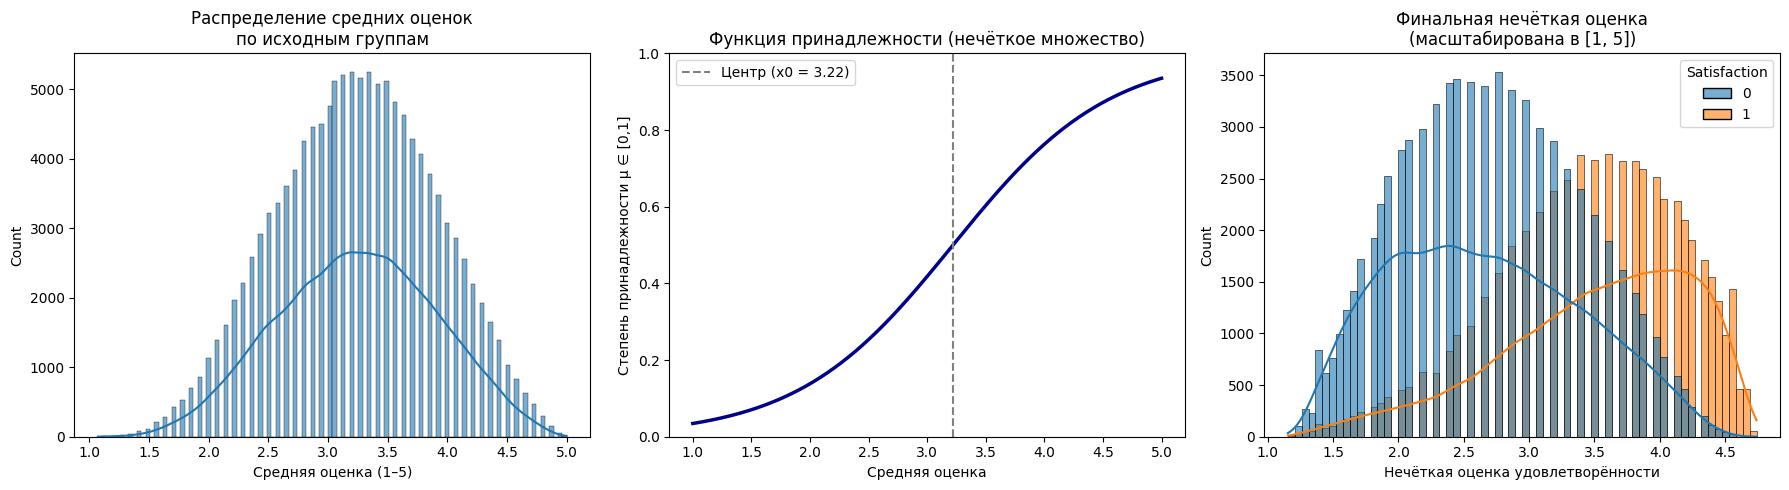

In [50]:
# ----------------------------
# 1. Нечёткое преобразование
# ----------------------------
x0 = 3.22 # центр сигмоиды
k = 1.5    # крутизна

df['mu'] = 1 / (1 + np.exp(-k * (df['avg_score'] - x0)))
df['Satisfaction_fuzzy'] = 1 + 4 * df['mu']  # масштаб в [1, 5]

# ----------------------------
# 2. Визуализация
# ----------------------------
#sns.set(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Распределение avg_score по группам
sns.histplot(data=df, x='avg_score', kde=True, ax=axes[0], alpha=0.6)
axes[0].set_title('Распределение средних оценок\nпо исходным группам')
axes[0].set_xlabel('Средняя оценка (1–5)')

# График 2: Функция принадлежности (сигмоида)
x_vals = np.linspace(1, 5, 200)  # типо средняя оценка
mu_vals = 1 / (1 + np.exp(-k * (x_vals - x0)))
axes[1].plot(x_vals, mu_vals, color='darkblue', lw=2.5)
axes[1].axvline(x0, color='gray', ls='--', label=f'Центр (x0 = {x0})')
axes[1].set_title('Функция принадлежности (нечёткое множество)')
axes[1].set_xlabel('Средняя оценка')
axes[1].set_ylabel('Степень принадлежности μ ∈ [0,1]')
axes[1].legend()
axes[1].set_ylim(0, 1)

# График 3: Распределение финальной нечёткой оценки
sns.histplot(data=df, x='Satisfaction_fuzzy', hue='Satisfaction', kde=True, ax=axes[2], alpha=0.6)
axes[2].set_title('Финальная нечёткая оценка\n(масштабирована в [1, 5])')
axes[2].set_xlabel('Нечёткая оценка удовлетворённости')

plt.tight_layout()
plt.show()

In [51]:
# Исходная доля 1
orig_satisfied = (df['Satisfaction'] == 1).mean()

# Доля в новой шкале
new_satisfied = (df['Satisfaction_fuzzy'] > 3.22).mean()

print(f"Исходная доля 'Satisfied': {orig_satisfied:.4f} ({orig_satisfied*100:.1f}%)")
print(f"Доля > 3.22 в новой шкале: {new_satisfied:.4f} ({new_satisfied*100:.1f}%)")

Исходная доля 'Satisfied': 0.4345 (43.4%)
Доля > 3.22 в новой шкале: 0.4201 (42.0%)


In [ ]:
# доли классов. СПОСОБ_1
print((df['Satisfaction_Score_Correlation']>=3.01).mean())
print((df['Satisfaction_Score_Correlation']<3.01).mean())

0.4389012024373103
0.5610987975626897


In [59]:
df=df.drop(['Satisfaction'],axis=1)

In [32]:
df

,ID,Gender,Age,Customer Type,Type of Travel,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Class_Economy,Class_Economy Plus,avg_score,Satisfaction_Score_Correlation,mu,Satisfaction_fuzzy
0,1,0,48,0,0,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,0,0,0,3.857,2.94,0.722220,3.888880
1,2,1,35,1,0,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,1,0,0,3.786,4.36,0.700357,3.801429
2,3,0,41,1,0,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,1,0,0,3.929,3.89,0.743359,3.973435
3,4,0,50,1,0,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,1,0,0,3.786,3.84,0.700357,3.801429
4,5,1,49,1,0,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,1,0,0,3.500,3.67,0.603483,3.413933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,0,28,1,1,447,2,3.0,4,4,4,4,2,5,1,4,4,4,5,4,4,4,0,0,1,3.786,3.07,0.700357,3.801429
129876,129877,0,41,1,1,308,0,0.0,5,3,5,3,4,5,2,5,2,2,4,3,2,5,0,0,1,3.571,2.25,0.628666,3.514666
129877,129878,0,42,1,1,337,6,14.0,5,2,4,2,1,3,3,4,3,3,4,2,3,5,0,0,1,3.143,2.21,0.471157,2.884628
129878,129879,0,50,1,1,337,31,22.0,4,4,3,4,1,4,4,5,3,3,4,5,3,5,1,0,1,3.714,3.64,0.677214,3.708858


# XGBoost 1 Способ

In [36]:
df.columns

Index(['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction',
       'Class_Economy', 'Class_Economy Plus', 'avg_score',
       'Satisfaction_Score_Correlation', 'mu', 'Satisfaction_fuzzy'],
      dtype='object')

In [52]:
features = ['Gender', 'Age', 'Customer Type', 'Type of Travel',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 
       #'Satisfaction',
       'Class_Economy', 'Class_Economy Plus']

In [53]:
X=df[features]
y=df['Satisfaction_Score_Correlation']
scaler=StandardScaler()
X_norm=scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

In [54]:
from xgboost import XGBRegressor

# Целевая функция для оптимизации гиперпараметров с помощью Hyperopt
def objective_xgb(params):
    """
    Функция, минимизируемая при подборе гиперпараметров.
    Обучает модель XGBoost с заданными параметрами и возвращает MSE на тестовой выборке.
    """
    # Создание модели XGBoost с переданными гиперпараметрами
    model_xgb = XGBRegressor(
        # Количество деревьев (итераций бустинга). Большее значение — лучше обучение, но дольше и риск переобучения.
        n_estimators=int(params['n_estimators']),
        
        # Скорость обучения (шаг градиентного спуска). Меньше — медленнее, но стабильнее; больше — быстрее, но может расходиться.
        learning_rate=params['learning_rate'],
        
        # Максимальная глубина каждого дерева. Контролирует сложность модели: чем глубже — тем сложнее и склоннее к переобучению.
        max_depth=int(params['max_depth']),
        
        # Минимальная сумма весов (число наблюдений) в листе дерева. Большее значение предотвращает переобучение.
        min_child_weight=int(params['min_child_weight']),
        
        # Доля объектов, используемых для построения каждого дерева (сэмплирование без замены). Уменьшает переобучение.
        subsample=params['subsample'],
        
        # Доля признаков, используемых для построения каждого дерева. Аналогично subsample, но для признаков.
        colsample_bytree=params['colsample_bytree'],
        
        # L1-регуляризация (штраф за абсолютные значения весов). Помогает уменьшить переобучение и сделать модель разреженной.
        reg_alpha=params['reg_alpha'],
        
        # L2-регуляризация (штраф за квадраты весов). Сглаживает веса, улучшает обобщающую способность.
        reg_lambda=params['reg_lambda'],
        
        # Минимальное уменьшение функции потерь, необходимое для разбиения узла. Чем выше — тем консервативнее дерево.
        gamma=params['gamma'],
        
        # Фиксированный seed для воспроизводимости результатов
        random_state=42,

        # Использовать все ядра процессора для ускорения обучения
        n_jobs=-1 
    )

    # Обучение модели на обучающей выборке
    model_xgb.fit(X_train, y_train)
    
    # Предсказание на тестовой выборке
    y_pred_xgb = model_xgb.predict(X_test)
    
    # Расчёт среднеквадратичной ошибки (MSE) — метрика для минимизации
    mse = mean_squared_error(y_test, y_pred_xgb)

    # Возврат результата в формате, требуемом Hyperopt
    return {'loss': mse, 'status': STATUS_OK}


# Пространство поиска гиперпараметров для XGBoost
space_xgb = {
    # Количество деревьев: от 50 до 800 с шагом 50
    'n_estimators': hp.quniform('n_estimators', 50, 800, 50),
    
    # Скорость обучения: непрерывное значение от 0.0001 до 0.3
    'learning_rate': hp.uniform('learning_rate', 0.0001, 0.3),  
    
    # Максимальная глубина дерева: целые числа от 4 до 12
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    
    # Минимальный вес дочернего узла: целые числа от 1 до 8
    'min_child_weight': hp.quniform('min_child_weight', 1, 8, 1),
    
    # Доля объектов для каждого дерева: от 70% до 95%
    'subsample': hp.uniform('subsample', 0.7, 0.95),
    
    # Доля признаков для каждого дерева: от 70% до 95%
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.95),
    
    # L1-регуляризация: от 0.01 до 0.5
    'reg_alpha': hp.uniform('reg_alpha', 0.01, 0.5),
    
    # L2-регуляризация: от 0.5 до 2.0
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    
    # Порог уменьшения потерь для разбиения узла: от 0.01 до 0.3
    'gamma': hp.uniform('gamma', 0.01, 0.3)
}

# Хранилище для истории испытаний Hyperopt
trials = Trials()

# Запуск оптимизации гиперпараметров с помощью алгоритма TPE (Tree-structured Parzen Estimator)
best_xgb = fmin(
    fn=objective_xgb,           # Целевая функция
    space=space_xgb,            # Пространство поиска
    algo=tpe.suggest,           # Алгоритм поиска (байесовская оптимизация)
    max_evals=40,               # Максимальное число итераций
    trials=trials,              # Хранение истории
    rstate=np.random.default_rng(42)  # Генератор случайных чисел для воспроизводимости
)


# Создание финальной модели с лучшими найденными гиперпараметрами
best_xgb_model = XGBRegressor(
    n_estimators=int(best_xgb['n_estimators']),
    learning_rate=best_xgb['learning_rate'],
    max_depth=int(best_xgb['max_depth']),
    min_child_weight=int(best_xgb['min_child_weight']),
    subsample=best_xgb['subsample'],
    colsample_bytree=best_xgb['colsample_bytree'],
    reg_alpha=best_xgb['reg_alpha'],
    reg_lambda=best_xgb['reg_lambda'],
    gamma=best_xgb['gamma'],
    random_state=42,
    n_jobs=-1
)

# Обучение финальной модели на всей обучающей выборке
best_xgb_model.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_xgb = best_xgb_model.predict(X_train)
y_pred_test_xgb = best_xgb_model.predict(X_test)

# Расчёт метрик качества на обучающей выборке
mse_train_xgb = mean_squared_error(y_train, y_pred_train_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

# Расчёт метрик качества на тестовой выборке
mse_test_xgb = mean_squared_error(y_test, y_pred_test_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

# Вывод результатов для анализа переобучения / недообучения
print(f"{'MSE'} train: {mse_train_xgb:.6f} | test: {mse_test_xgb:.6f} | delta: {mse_test_xgb - mse_train_xgb:.6f}")
print(f"{'MAE'} train: {mae_train_xgb:.6f} | test: {mae_test_xgb:.6f} | delta: {mae_test_xgb - mae_train_xgb:.6f}")
print(f"{'R²'}  train: {r2_train_xgb:.6f} | test: {r2_test_xgb:.6f} | delta: {r2_test_xgb - r2_train_xgb:.6f}")

100%|██████████| 40/40 [03:31<00:00,  5.28s/trial, best loss: 0.034604039154846736]
MSE train: 0.015302 | test: 0.034604 | delta: 0.019302
MAE train: 0.096237 | test: 0.143886 | delta: 0.047649
R²  train: 0.977662 | test: 0.949261 | delta: -0.028401


<Axes: xlabel='Satisfaction_Score_Correlation'>

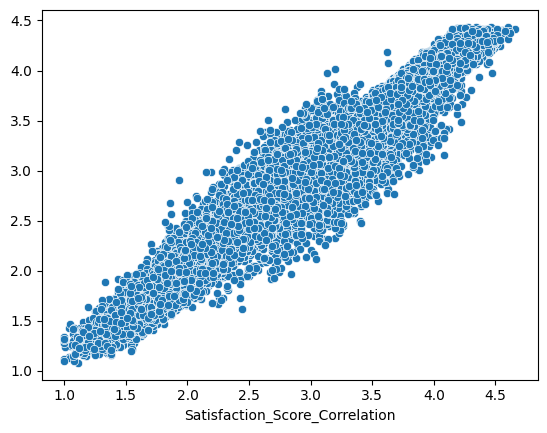

In [55]:
sns.scatterplot(x = y_test ,y = y_pred_test_xgb)

<Axes: xlabel='Satisfaction_Score_Correlation', ylabel='Count'>

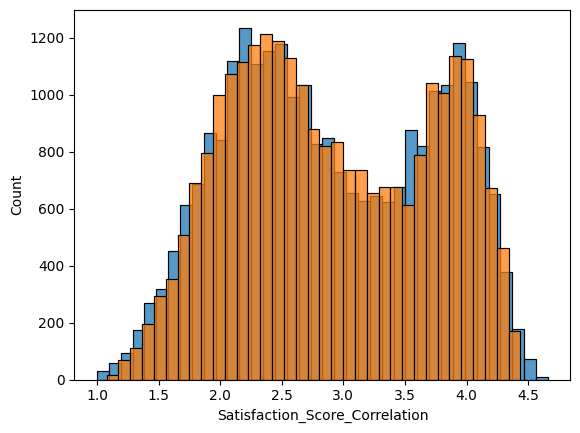

In [57]:
sns.histplot(x = y_test)
sns.histplot(x = y_pred_test_xgb)

# XGBoost. Способ 2 (fuzzy)

In [60]:
X=df[features]
y=df['Satisfaction_fuzzy']
# scaler=StandardScaler()
# X_norm=scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
from xgboost import XGBRegressor

# Целевая функция для оптимизации гиперпараметров с помощью Hyperopt
def objective_xgb(params):
    """
    Функция, минимизируемая при подборе гиперпараметров.
    Обучает модель XGBoost с заданными параметрами и возвращает MSE на тестовой выборке.
    """
    # Создание модели XGBoost с переданными гиперпараметрами
    model_xgb = XGBRegressor(
        # Количество деревьев (итераций бустинга). Большее значение — лучше обучение, но дольше и риск переобучения.
        n_estimators=int(params['n_estimators']),
        
        # Скорость обучения (шаг градиентного спуска). Меньше — медленнее, но стабильнее; больше — быстрее, но может расходиться.
        learning_rate=params['learning_rate'],
        
        # Максимальная глубина каждого дерева. Контролирует сложность модели: чем глубже — тем сложнее и склоннее к переобучению.
        max_depth=int(params['max_depth']),
        
        # Минимальная сумма весов (число наблюдений) в листе дерева. Большее значение предотвращает переобучение.
        min_child_weight=int(params['min_child_weight']),
        
        # Доля объектов, используемых для построения каждого дерева (сэмплирование без замены). Уменьшает переобучение.
        subsample=params['subsample'],
        
        # Доля признаков, используемых для построения каждого дерева. Аналогично subsample, но для признаков.
        colsample_bytree=params['colsample_bytree'],
        
        # L1-регуляризация (штраф за абсолютные значения весов). Помогает уменьшить переобучение и сделать модель разреженной.
        reg_alpha=params['reg_alpha'],
        
        # L2-регуляризация (штраф за квадраты весов). Сглаживает веса, улучшает обобщающую способность.
        reg_lambda=params['reg_lambda'],
        
        # Минимальное уменьшение функции потерь, необходимое для разбиения узла. Чем выше — тем консервативнее дерево.
        gamma=params['gamma'],
        
        # Фиксированный seed для воспроизводимости результатов
        random_state=42,

        # Использовать все ядра процессора для ускорения обучения
        n_jobs=-1 
    )

    # Обучение модели на обучающей выборке
    model_xgb.fit(X_train, y_train)
    
    # Предсказание на тестовой выборке
    y_pred_xgb = model_xgb.predict(X_test)
    
    # Расчёт среднеквадратичной ошибки (MSE) — метрика для минимизации
    mse = mean_squared_error(y_test, y_pred_xgb)

    # Возврат результата в формате, требуемом Hyperopt
    return {'loss': mse, 'status': STATUS_OK}


# Пространство поиска гиперпараметров для XGBoost
space_xgb = {
    # Количество деревьев: от 50 до 800 с шагом 50
    'n_estimators': hp.quniform('n_estimators', 50, 800, 50),
    
    # Скорость обучения: непрерывное значение от 0.0001 до 0.3
    'learning_rate': hp.uniform('learning_rate', 0.0001, 0.3),  
    
    # Максимальная глубина дерева: целые числа от 4 до 12
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    
    # Минимальный вес дочернего узла: целые числа от 1 до 8
    'min_child_weight': hp.quniform('min_child_weight', 1, 8, 1),
    
    # Доля объектов для каждого дерева: от 70% до 95%
    'subsample': hp.uniform('subsample', 0.7, 0.95),
    
    # Доля признаков для каждого дерева: от 70% до 95%
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.95),
    
    # L1-регуляризация: от 0.01 до 0.5
    'reg_alpha': hp.uniform('reg_alpha', 0.01, 0.5),
    
    # L2-регуляризация: от 0.5 до 2.0
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
    
    # Порог уменьшения потерь для разбиения узла: от 0.01 до 0.3
    'gamma': hp.uniform('gamma', 0.01, 0.3)
}

# Хранилище для истории испытаний Hyperopt
trials = Trials()

# Запуск оптимизации гиперпараметров с помощью алгоритма TPE (Tree-structured Parzen Estimator)
best_xgb = fmin(
    fn=objective_xgb,           # Целевая функция
    space=space_xgb,            # Пространство поиска
    algo=tpe.suggest,           # Алгоритм поиска (байесовская оптимизация)
    max_evals=40,               # Максимальное число итераций
    trials=trials,              # Хранение истории
    rstate=np.random.default_rng(42)  # Генератор случайных чисел для воспроизводимости
)


# Создание финальной модели с лучшими найденными гиперпараметрами
best_xgb_model = XGBRegressor(
    n_estimators=int(best_xgb['n_estimators']),
    learning_rate=best_xgb['learning_rate'],
    max_depth=int(best_xgb['max_depth']),
    min_child_weight=int(best_xgb['min_child_weight']),
    subsample=best_xgb['subsample'],
    colsample_bytree=best_xgb['colsample_bytree'],
    reg_alpha=best_xgb['reg_alpha'],
    reg_lambda=best_xgb['reg_lambda'],
    gamma=best_xgb['gamma'],
    random_state=42,
    n_jobs=-1
)

# Обучение финальной модели на всей обучающей выборке
best_xgb_model.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_xgb = best_xgb_model.predict(X_train)
y_pred_test_xgb = best_xgb_model.predict(X_test)

# Расчёт метрик качества на обучающей выборке
mse_train_xgb = mean_squared_error(y_train, y_pred_train_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

# Расчёт метрик качества на тестовой выборке
mse_test_xgb = mean_squared_error(y_test, y_pred_test_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

# Вывод результатов для анализа переобучения / недообучения
print(f"{'MSE'} train: {mse_train_xgb:.6f} | test: {mse_test_xgb:.6f} | delta: {mse_test_xgb - mse_train_xgb:.6f}")
print(f"{'MAE'} train: {mae_train_xgb:.6f} | test: {mae_test_xgb:.6f} | delta: {mae_test_xgb - mae_train_xgb:.6f}")
print(f"{'R²'}  train: {r2_train_xgb:.6f} | test: {r2_test_xgb:.6f} | delta: {r2_test_xgb - r2_train_xgb:.6f}")

100%|██████████| 40/40 [02:42<00:00,  4.07s/trial, best loss: 0.0012362115795612185]
MSE train: 0.001051 | test: 0.001236 | delta: 0.000186
MAE train: 0.024259 | test: 0.025979 | delta: 0.001720
R²  train: 0.998521 | test: 0.998260 | delta: -0.000260


<Axes: xlabel='Satisfaction_fuzzy'>

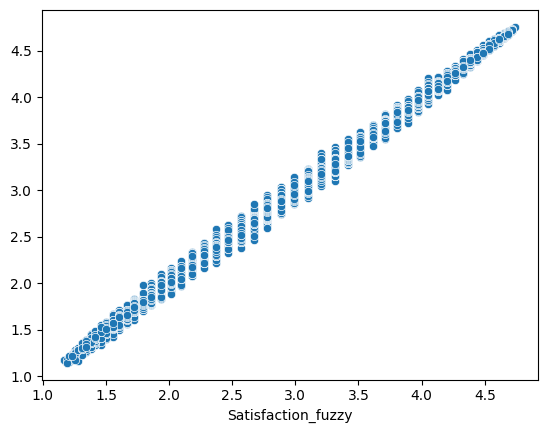

In [62]:
sns.scatterplot(x = y_test ,y = y_pred_test_xgb)

<Axes: xlabel='Satisfaction_fuzzy', ylabel='Count'>

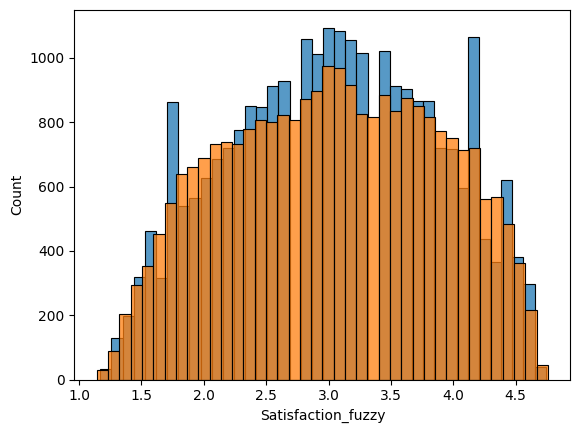

In [63]:
sns.histplot(x = y_test)
sns.histplot(x = y_pred_test_xgb)

# Feature importance on XGBRegressor

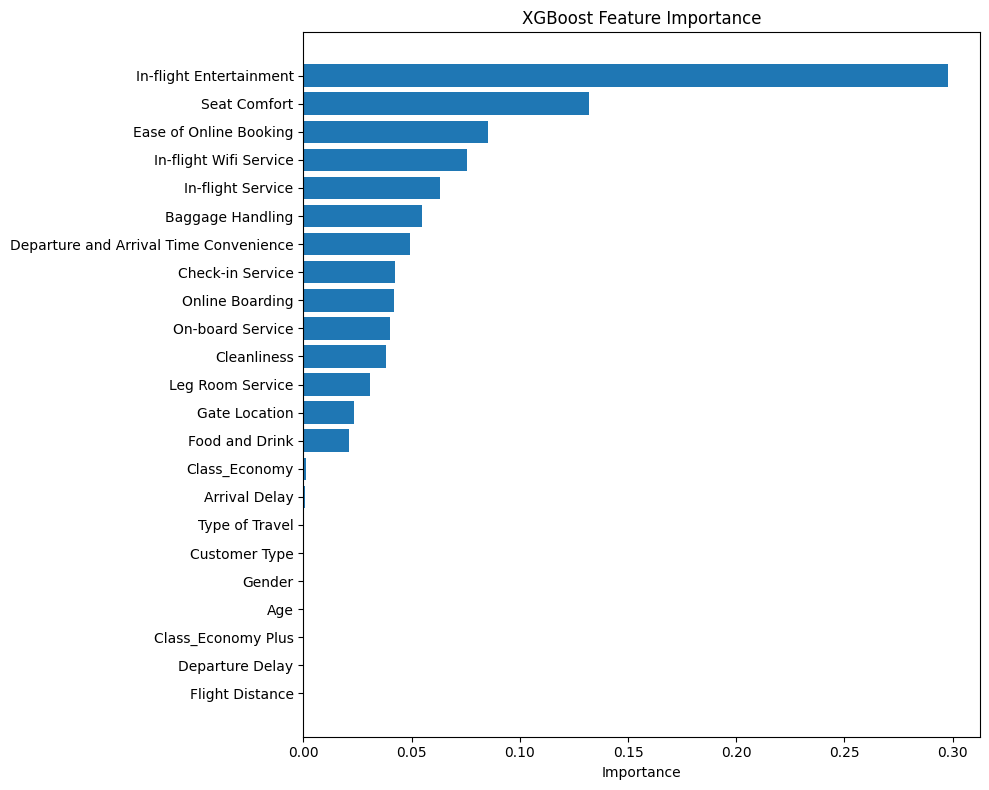

In [65]:
# Обучение модели
best_xgb_model.fit(X_train[features], y_train)

# Получение важности признаков
importance = best_xgb_model.feature_importances_

# Создание DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# print(importance_df)

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [71]:
importance_df['feature'].to_list()

['In-flight Entertainment',
 'Seat Comfort',
 'Ease of Online Booking',
 'In-flight Wifi Service',
 'In-flight Service',
 'Baggage Handling',
 'Departure and Arrival Time Convenience',
 'Check-in Service',
 'Online Boarding',
 'On-board Service',
 'Cleanliness',
 'Leg Room Service',
 'Gate Location',
 'Food and Drink',
 'Class_Economy',
 'Arrival Delay',
 'Type of Travel',
 'Customer Type',
 'Gender',
 'Age',
 'Class_Economy Plus',
 'Departure Delay',
 'Flight Distance']

In [69]:
df['In-flight Entertainment'].value_counts(dropna=False)

In-flight Entertainment
4    36682
5    31451
3    23805
2    21897
1    15634
0       18
Name: count, dtype: int64

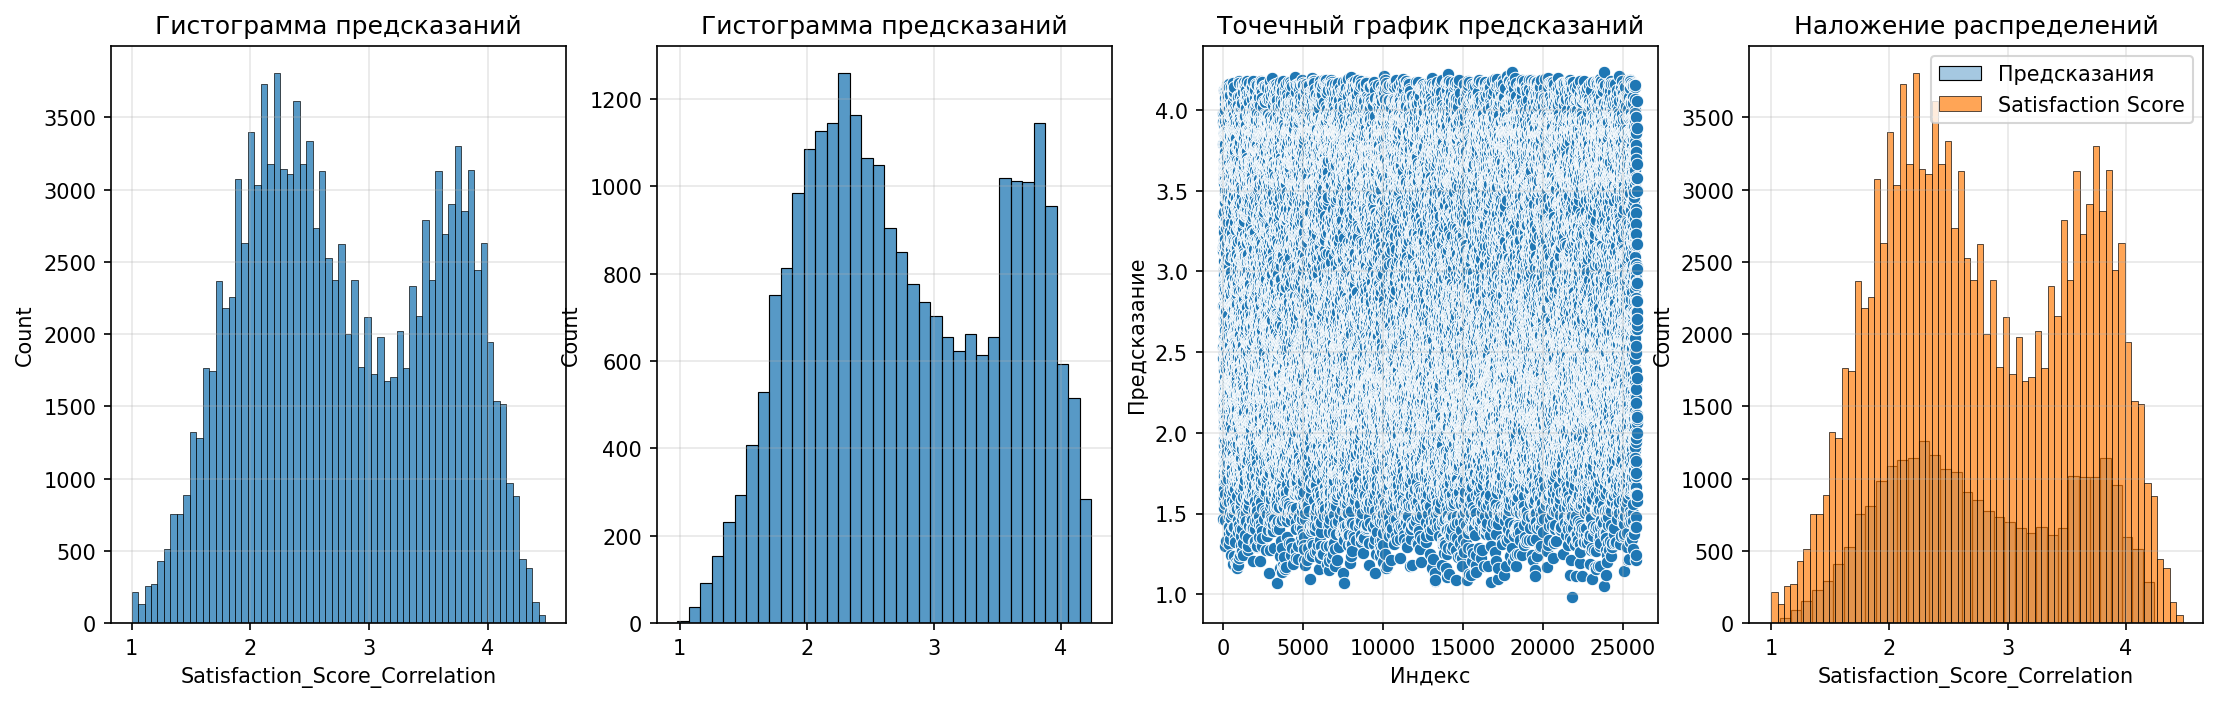

In [63]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний')
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Целевая функция для оптимизации гиперпараметров модели Gradient Boosting
def objective_gb(params):
    """
    Обучает модель GradientBoostingRegressor с заданными гиперпараметрами,
    делает предсказание на тестовой выборке и возвращает MSE как значение потерь.
    Используется в Hyperopt для поиска оптимальных параметров.
    """
    model_gb = GradientBoostingRegressor(
        # Общее количество деревьев (бустинговых итераций).
        # Большее значение — выше сложность и риск переобучения, но лучше подгонка.
        n_estimators=int(params['n_estimators']),
        
        # Скорость обучения (learning rate): масштабирует вклад каждого дерева.
        # Меньшее значение требует больше деревьев, но делает обучение устойчивее.
        learning_rate=params['learning_rate'],
        
        # Максимальная глубина каждого дерева. Контролирует сложность модели.
        # Глубокие деревья хорошо аппроксимируют данные, но склонны к переобучению.
        max_depth=int(params['max_depth']),
        
        # Минимальное число объектов, необходимое для разбиения внутреннего узла.
        # Большее значение предотвращает создание слишком мелких узлов → снижает переобучение.
        min_samples_split=int(params['min_samples_split']),
        
        # Минимальное число объектов, требуемое в листе (терминальном узле).
        # Аналогично min_samples_split, но для листьев. Увеличение → более гладкая модель.
        min_samples_leaf=int(params['min_samples_leaf']),
        
        # Доля признаков, используемых для построения каждого дерева.
        # Может быть float (доля), int (абсолютное число) или "sqrt", "log2".
        # Уменьшение → повышает разнообразие деревьев и снижает переобучение.
        max_features=params['max_features_val'], 
        
        # Доля обучающих данных, используемая для обучения каждого дерева (сэмплирование без замены).
        # Значение < 1.0 включает стохастический градиентный бустинг → уменьшает переобучение.
        subsample=params['subsample'],
        
        # Фиксированный seed для воспроизводимости
        random_state=42,
        
        # Доля данных, выделяемая из обучающей выборки для ранней остановки (валидация).
        # Используется только если заданы n_iter_no_change и tol.
        validation_fraction=0.1
    )

    # Обучение модели на обучающей выборке
    model_gb.fit(X_train, y_train)
    
    # Предсказание на тестовой выборке
    y_pred_gb = model_gb.predict(X_test)
    
    # Расчёт среднеквадратичной ошибки (MSE) — метрика для минимизации
    mse = mean_squared_error(y_test, y_pred_gb)

    # Возврат результата в формате Hyperopt
    return {'loss': mse, 'status': STATUS_OK}


# Возможные значения для гиперпараметра max_features (в долях от общего числа признаков)
max_features_opts = [0.7, 0.8, 0.9, 1.0]  

# Пространство поиска гиперпараметров для Hyperopt
space_gb = {
    # Количество деревьев: от 100 до 400 с шагом 50
    'n_estimators': hp.quniform('n_estimators', 100, 400, 50),
    
    # Скорость обучения: от 0.05 до 0.2 (типичный диапазон для GBM)
    'learning_rate': hp.uniform('learning_rate', 0.05, 0.2),
    
    # Максимальная глубина дерева: от 4 до 7 (умеренная сложность)
    'max_depth': hp.quniform('max_depth', 4, 7, 1),
    
    # Мин. число объектов для разбиения узла: 5, 10 или 15
    'min_samples_split': hp.quniform('min_samples_split', 5, 15, 5),
    
    # Мин. число объектов в листе: 3, 6 или 9
    'min_samples_leaf': hp.quniform('min_samples_leaf', 3, 10, 3),
    
    # Доля объектов для каждого дерева: от 80% до 100% (стохастический бустинг)
    'subsample': hp.uniform('subsample', 0.8, 1.0),
    
    # Выбор одного из предопределённых значений max_features
    'max_features_val': hp.choice('max_features_val', max_features_opts)
}

# Хранилище для сохранения истории испытаний Hyperopt
trials = Trials()

# Запуск байесовской оптимизации с помощью алгоритма TPE
best_gb = fmin(
    fn=objective_gb,                    # Целевая функция
    space=space_gb,                     # Пространство гиперпараметров
    algo=tpe.suggest,                   # Алгоритм поиска (Tree-structured Parzen Estimator)
    max_evals=5,                        # Малое число итераций (для теста); обычно 30–100+
    trials=trials,                      # Сохранение результатов
    rstate=np.random.default_rng(42),   # Генератор случайных чисел для воспроизводимости
    show_progressbar=True               # Отображение прогресс-бара
)


# Вывод лучших найденных гиперпараметров
print(f"n_estimators: {int(best_gb['n_estimators'])}")
print(f"learning_rate: {best_gb['learning_rate']:.6f}")
print(f"max_depth: {int(best_gb['max_depth'])}")
print(f"min_samples_split: {int(best_gb['min_samples_split'])}")
print(f"min_samples_leaf: {int(best_gb['min_samples_leaf'])}")
print(f"subsample: {best_gb['subsample']:.6f}")
# hp.choice возвращает индекс, поэтому извлекаем значение из списка
print(f"max_features: {max_features_opts[best_gb['max_features_val']]}")


# Создание финальной модели с лучшими гиперпараметрами
best_gb_model = GradientBoostingRegressor(
    n_estimators=int(best_gb['n_estimators']),
    learning_rate=best_gb['learning_rate'],
    max_depth=int(best_gb['max_depth']),
    min_samples_leaf=int(best_gb['min_samples_leaf']),
    min_samples_split=int(best_gb['min_samples_split']),
    max_features=max_features_opts[best_gb['max_features_val']],
    subsample=best_gb['subsample'],
    random_state=42,
    
    # Ранняя остановка: прекратить обучение, если ошибка на валидации не улучшается
    # в течение 10 итераций
    n_iter_no_change=10,
    
    # Доля данных для валидации (должна совпадать с validation_fraction в objective_gb)
    validation_fraction=0.1,
    
    # Порог для определения "улучшения" (изменение MSE должно быть > tol)
    tol=1e-4
)

# Обучение финальной модели
best_gb_model.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
y_pred_train_gb = best_gb_model.predict(X_train)
y_pred_test_gb = best_gb_model.predict(X_test)

# Метрики на обучающей выборке
mse_train_gb = mean_squared_error(y_train, y_pred_train_gb)
mae_train_gb = mean_absolute_error(y_train, y_pred_train_gb)
r2_train_gb = r2_score(y_train, y_pred_train_gb)

# Метрики на тестовой выборке
mse_test_gb = mean_squared_error(y_test, y_pred_test_gb)
mae_test_gb = mean_absolute_error(y_test, y_pred_test_gb)
r2_test_gb = r2_score(y_test, y_pred_test_gb)

# Вывод результатов для анализа переобучения
print(f"{'MSE'} train: {mse_train_gb:.6f} | test: {mse_test_gb:.6f} | delta: {mse_test_gb - mse_train_gb:.6f}")
print(f"{'MAE'} train: {mae_train_gb:.6f} | test: {mae_test_gb:.6f} | delta: {mae_test_gb - mae_train_gb:.6f}")
print(f"{'R²'}  train: {r2_train_gb:.6f} | test: {r2_test_gb:.6f} | delta: {r2_test_gb - r2_train_gb:.6f}")

  0%|          | 0/5 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 5/5 [05:28<00:00, 65.76s/trial, best loss: 0.03939535419154314] 
n_estimators: 100
learning_rate: 0.183672
max_depth: 6
min_samples_split: 10
min_samples_leaf: 3
subsample: 0.829393
max_features: 0.9
MSEtrain 0.03757080091807634 test: 0.04023175043254307 delta: 0.002660949514466729
MAE train0.15350996586991883 test: 0.15878824097207103 delta: 0.005278275102152202
R² train0.9411973659720257 test: 0.9368818090696377 delta: -0.004315556902388051


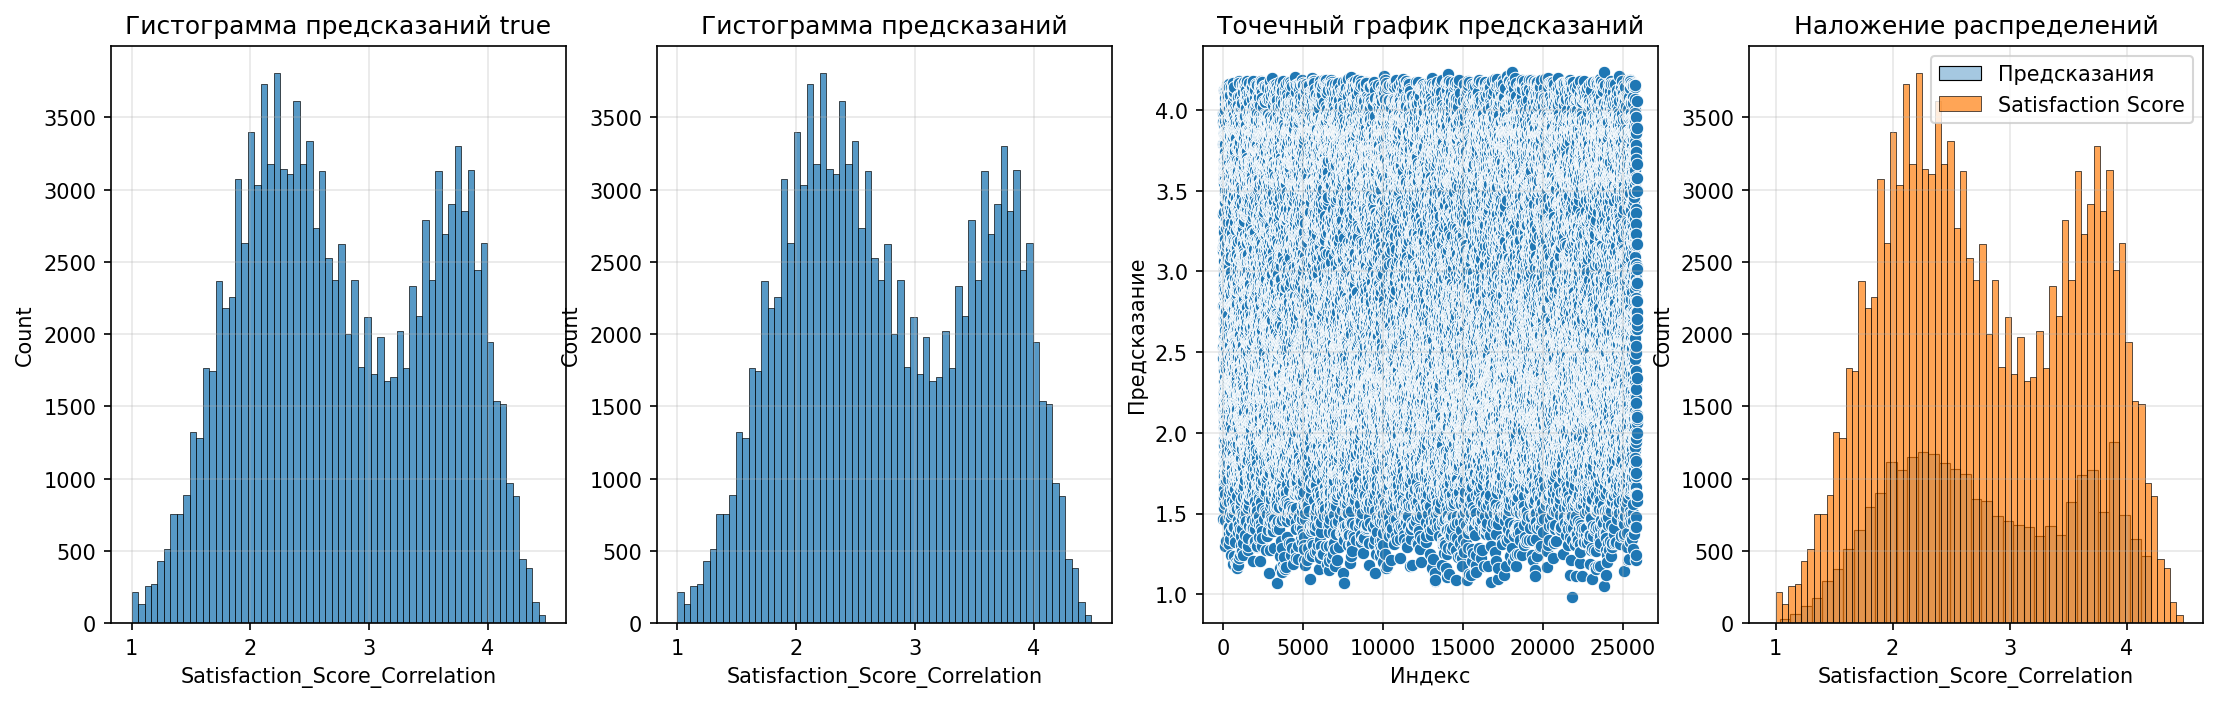

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний true')
axes[0].grid(True, alpha=0.3)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_test_gb, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

In [66]:
def objective_random_forest(params):
    model_rf = RandomForestRegressor(
        n_estimators=int(params['n_estimators']),
        max_depth=params['max_depth'],
        min_samples_split=int(params['min_samples_split']),
        min_samples_leaf=int(params['min_samples_leaf']),
        max_features=params['max_features'],
        min_impurity_decrease=params['min_impurity_decrease'],
        random_state=42,
        n_jobs=-1,  
        verbose=0
    )

    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_rf)

    return {'loss': mse, 'status': STATUS_OK}

space_random_forest = {
    'n_estimators': hp.quniform('n_estimators', 1000, 1200, 50),  
    'max_depth': hp.choice('max_depth', [6, 8, 10, 12, 15]),   
    'min_samples_split': hp.quniform('min_samples_split', 5, 20, 5),  
    'min_samples_leaf': hp.quniform('min_samples_leaf', 3, 15, 3),    
    'max_features': hp.choice('max_features', ['sqrt', 0.8, 0.9]),    
    'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0.0, 0.0001)  
}
trials = Trials()

best_rf = fmin(
    fn=objective_random_forest,
    space=space_random_forest,
    algo=tpe.suggest,
    max_evals=5,
    trials=trials,
    rstate=np.random.default_rng(42)
)


max_depth_values = [4, 5, 6, 7, 8, 9, 10, 11, 12]
best_max_depth = max_depth_values[best_rf['max_depth']]

best_max_features_rf = max_features_opts[best_rf['max_features']]

print(f"n_estimators: {int(best_rf['n_estimators'])}")
print(f"max_depth: {best_max_depth}")
print(f"min_samples_split: {int(best_rf['min_samples_split'])}")
print(f"min_samples_leaf: {int(best_rf['min_samples_leaf'])}")
print(f"max_features: {best_max_features_rf}")
print(f"min_impurity_decrease: {best_rf['min_impurity_decrease']}")

best_rf_model = RandomForestRegressor(
    n_estimators=int(best_rf['n_estimators']),
    max_depth=best_max_depth,
    min_samples_leaf=int(best_rf['min_samples_leaf']),      
    min_samples_split=int(best_rf['min_samples_split']),    
    max_features=best_max_features_rf,
    min_impurity_decrease=best_rf['min_impurity_decrease'],
    random_state=42,
)

best_rf_model.fit(X_train, y_train)
y_pred_train_rf = best_rf_model.predict(X_train)
y_pred_test_rf = best_rf_model.predict(X_test)

mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)

mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print(f"{'MSE'}  train: {mse_train_rf}  test: {mse_test_rf}  delta: {mse_test_rf - mse_train_rf}")
print(f"{'MAE'}  train: {mae_train_rf}  test: {mae_test_rf}  delta: {mae_test_rf - mae_train_rf}")
print(f"{'R²'}  train: {r2_train_rf}  test: {r2_test_rf}  delta: {r2_test_rf - r2_train_rf}")
    

  0%|          | 0/5 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 5/5 [07:13<00:00, 86.61s/trial, best loss: 0.04842919167962616] 
n_estimators: 1050
max_depth: 6
min_samples_split: 15
min_samples_leaf: 12
max_features: 0.9
min_impurity_decrease: 5.993618908140053e-06
MSE  train: 0.07372074004104112  test: 0.07483951790231513  delta: 0.0011187778612740118
MAE  train: 0.20877017778819526  test: 0.21041677805662332  delta: 0.0016466002684280556
R²  train: 0.8846185444287642  test: 0.8825868889792672  delta: -0.0020316554494970163


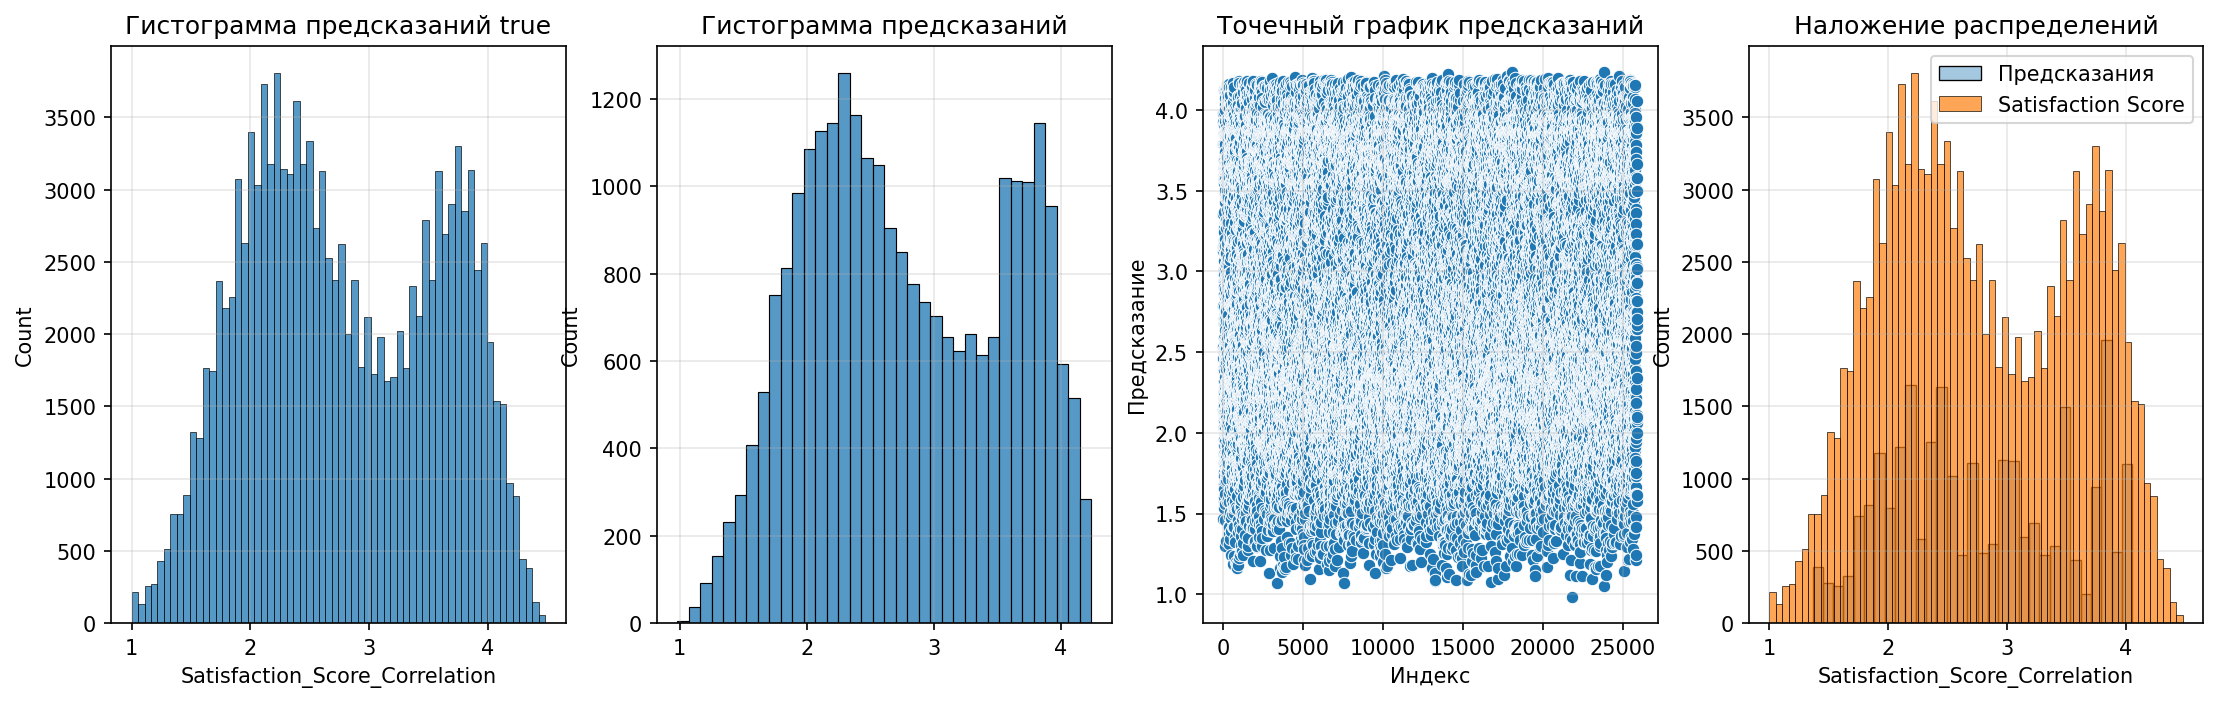

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний true')
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_test_rf, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

In [68]:

def objective_linear(params):
    model_lr = LinearRegression(
        fit_intercept=params['fit_intercept'],
        copy_X=params['copy_X'],
        n_jobs=int(params['n_jobs'])
    )
    
    model_lr.fit(X_train, y_train)
    y_pred_lr = model_lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_lr)
    
    return {'loss': mse, 'status': STATUS_OK}
    

space_linear = {
    'fit_intercept': hp.choice('fit_intercept', [True, False]),
    'copy_X': hp.choice('copy_X', [True, False]),
    'n_jobs': hp.choice('n_jobs', [-1, 1, 2, 4])
}

trials = Trials()

best_linear = fmin(
    fn=objective_linear,
    space=space_linear,
    algo=tpe.suggest,
    max_evals=200,  
    trials=trials,
    rstate=np.random.default_rng(42)
)


best_lr_model = LinearRegression(
    fit_intercept=[True, False][best_linear['fit_intercept']],
    copy_X=[True, False][best_linear['copy_X']],
    n_jobs=[-1, 1, 2, 4][best_linear['n_jobs']]
)

best_lr_model.fit(X_train, y_train)
y_pred_train_lr = best_lr_model.predict(X_train)
y_pred_test_lr = best_lr_model.predict(X_test)

mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)

mse_test_lr = mean_squared_error(y_test, y_pred_test_lr)
mae_test_lr = mean_absolute_error(y_test, y_pred_test_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)

print(f"{'MSE'}train {mse_train_lr} test: {mse_test_lr} delta: {mse_test_lr - mse_train_lr}")
print(f"{'MAE'} train{mae_train_lr} test: {mae_test_lr} delta: {mae_test_lr - mae_train_lr}")
print(f"{'R²'} train{r2_train_lr} test: {r2_test_lr} delta: {r2_test_lr - r2_train_lr}")



  0%|          | 0/200 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 200/200 [00:15<00:00, 12.73trial/s, best loss: 0.07426441356058042]
MSEtrain 0.07305870995262907 test: 0.07426755472842976 delta: 0.0012088447758006882
MAE train0.21227654800634638 test: 0.2144582201829559 delta: 0.002181672176609528
R² train0.8856546978259006 test: 0.8834842220663512 delta: -0.0021704757595493174


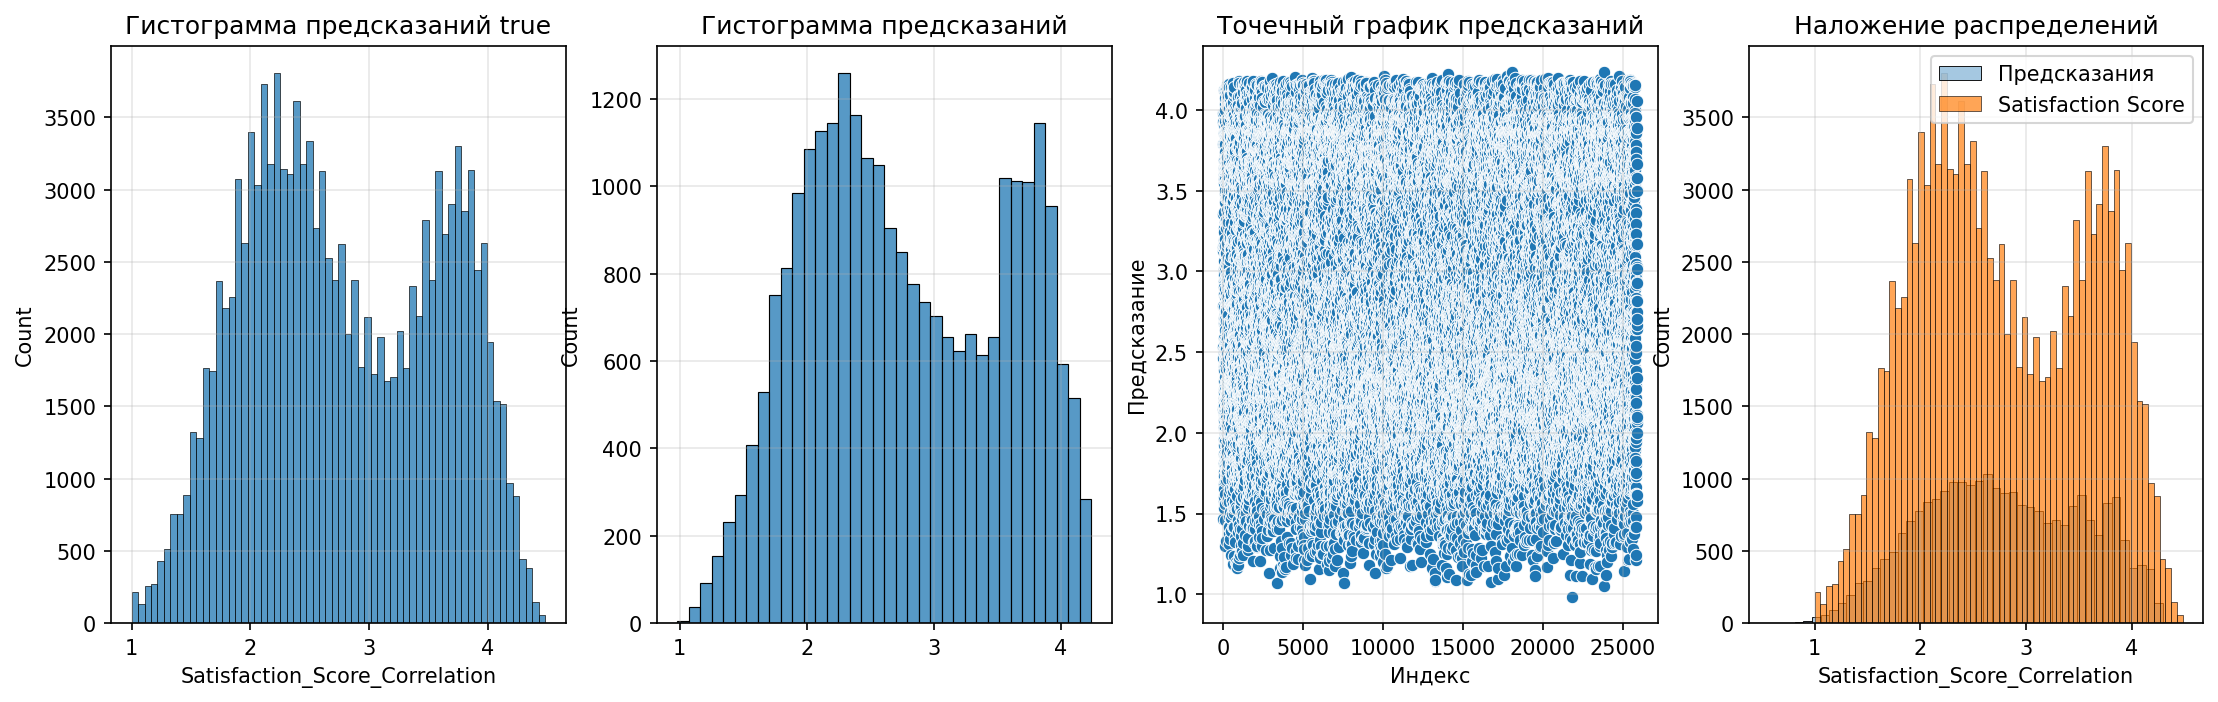

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний true')
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_test_lr, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

In [70]:

def objective_lgb(params):
    model_lgb = LGBMRegressor(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        n_jobs=-1 ,# ускорение
        verbose=-1
    )

    model_lgb.fit(X_train, y_train)
    y_pred_lgb = model_lgb.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_lgb)

    return {'loss': mse, 'status': STATUS_OK}

space_lgb = {
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),  
    'max_depth': hp.quniform('max_depth', 3, 12, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 5),
    'min_child_samples': hp.quniform('min_child_samples', 5, 100, 5),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

trials = Trials()

best_lgb = fmin(
    fn=objective_lgb,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)



best_lgb_model = LGBMRegressor(
    n_estimators=int(best_lgb['n_estimators']),
    learning_rate=best_lgb['learning_rate'],
    max_depth=int(best_lgb['max_depth']),
    num_leaves=int(best_lgb['num_leaves']),
    min_child_samples=int(best_lgb['min_child_samples']),
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    random_state=42,
    n_jobs=-1,
    verbose=-1# 2 мой ноутбук не тянет
)

best_lgb_model.fit(X_train, y_train)
y_pred_train_lgb = best_lgb_model.predict(X_train)
y_pred_test_lgb = best_lgb_model.predict(X_test)

mse_train_lgb = mean_squared_error(y_train, y_pred_train_lgb)
mae_train_lgb = mean_absolute_error(y_train, y_pred_train_lgb)
r2_train_lgb = r2_score(y_train, y_pred_train_lgb)

mse_test_lgb = mean_squared_error(y_test, y_pred_test_lgb)
mae_test_lgb = mean_absolute_error(y_test, y_pred_test_lgb)
r2_test_lgb = r2_score(y_test, y_pred_test_lgb)

print(f"{'MSE'}train {mse_train_lgb} test: {mse_test_lgb} delta: {mse_test_lgb - mse_train_lgb}")
print(f"{'MAE'} train{mae_train_lgb} test: {mae_test_lgb} delta: {mae_test_lgb - mae_train_lgb}")
print(f"{'R²'} train{r2_train_lgb} test: {r2_test_lgb} delta: {r2_test_lgb - r2_train_lgb}")

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  4%|▍         | 2/50 [00:09<03:38,  4.55s/trial, best loss: 0.0377013971898758]

c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  6%|▌         | 3/50 [00:12<02:57,  3.79s/trial, best loss: 0.0377013971898758]

...

 98%|█████████▊| 49/50 [03:08<00:02,  2.93s/trial, best loss: 0.0373970034734817]

c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(

c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



100%|██████████| 50/50 [03:13<00:00,  3.86s/trial, best loss: 0.0373970034734817]


c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kiril\anaconda3\envs\ML_TMS_test\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MSEtrain 0.02822024304487732 test: 0.0373970034734817 delta: 0.009176760428604384
MAE train0.1343967570622952 test: 0.15356462331981235 delta: 0.019167866257517152
R² train0.9558320668338478 test: 0.9413291447653913 delta: -0.014502922068456492


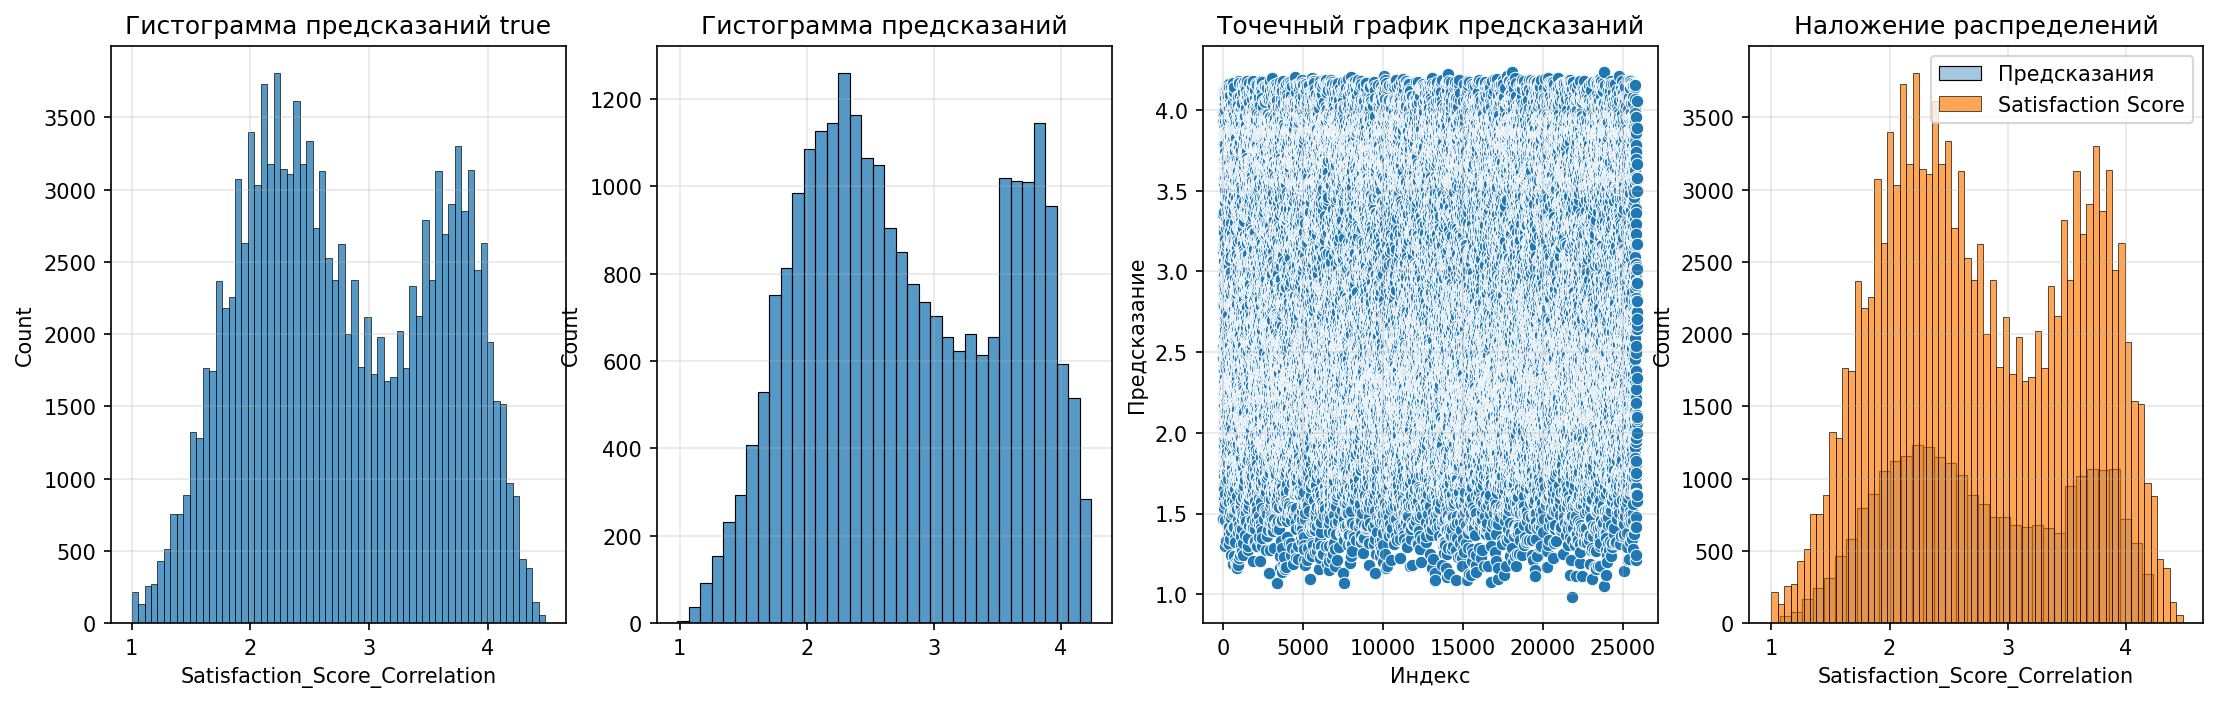

In [71]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний true')
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_test_lgb, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

In [72]:

def objective_catboost(params):
    model_cb = CatBoostRegressor(
        iterations=int(params['iterations']),
        learning_rate=params['learning_rate'],
        depth=int(params['depth']),
        l2_leaf_reg=params['l2_leaf_reg'],
        random_strength=params['random_strength'],
        bagging_temperature=params['bagging_temperature'],
        border_count=int(params['border_count']),
        random_state=42,
        verbose=False,  
        thread_count=-1  # ускорение
    )

    model_cb.fit(X_train, y_train)
    y_pred_cb = model_cb.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_cb)

    return {'loss': mse, 'status': STATUS_OK}

space_catboost = {
    'iterations': hp.quniform('iterations', 100, 1000, 50), 
    'learning_rate': hp.loguniform('learning_rate', -3, 0),  
    'depth': hp.quniform('depth', 4, 10, 1),
    'l2_leaf_reg': hp.uniform('l2_leaf_reg', 1, 10),
    'random_strength': hp.uniform('random_strength', 0, 2),
    'bagging_temperature': hp.uniform('bagging_temperature', 0, 1),
    'border_count': hp.quniform('border_count', 32, 255, 1)
}

trials = Trials()

best_cb = fmin(
    fn=objective_catboost,
    space=space_catboost,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials,
    rstate=np.random.default_rng(42)
)


best_cb_model = CatBoostRegressor(
    iterations=int(best_cb['iterations']),
    learning_rate=best_cb['learning_rate'],
    depth=int(best_cb['depth']),
    l2_leaf_reg=best_cb['l2_leaf_reg'],
    random_strength=best_cb['random_strength'],
    bagging_temperature=best_cb['bagging_temperature'],
    border_count=int(best_cb['border_count']),
    random_state=42,
    verbose=False,
    thread_count=-1
)

best_cb_model.fit(X_train, y_train)
y_pred_cb = best_cb_model.predict(X_test)

mse_cb = mean_squared_error(y_test, y_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

print(f"CatBoost MSE: {mse_cb}")
print(f"CatBoost MAE: {mae_cb}")
print(f"CatBoost R2: {r2_cb}")

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 10/10 [01:45<00:00, 10.60s/trial, best loss: 0.03678049186097343]
CatBoost MSE: 0.03678049186097343
CatBoost MAE: 0.15285564753590705
CatBoost R2: 0.9422963683450446


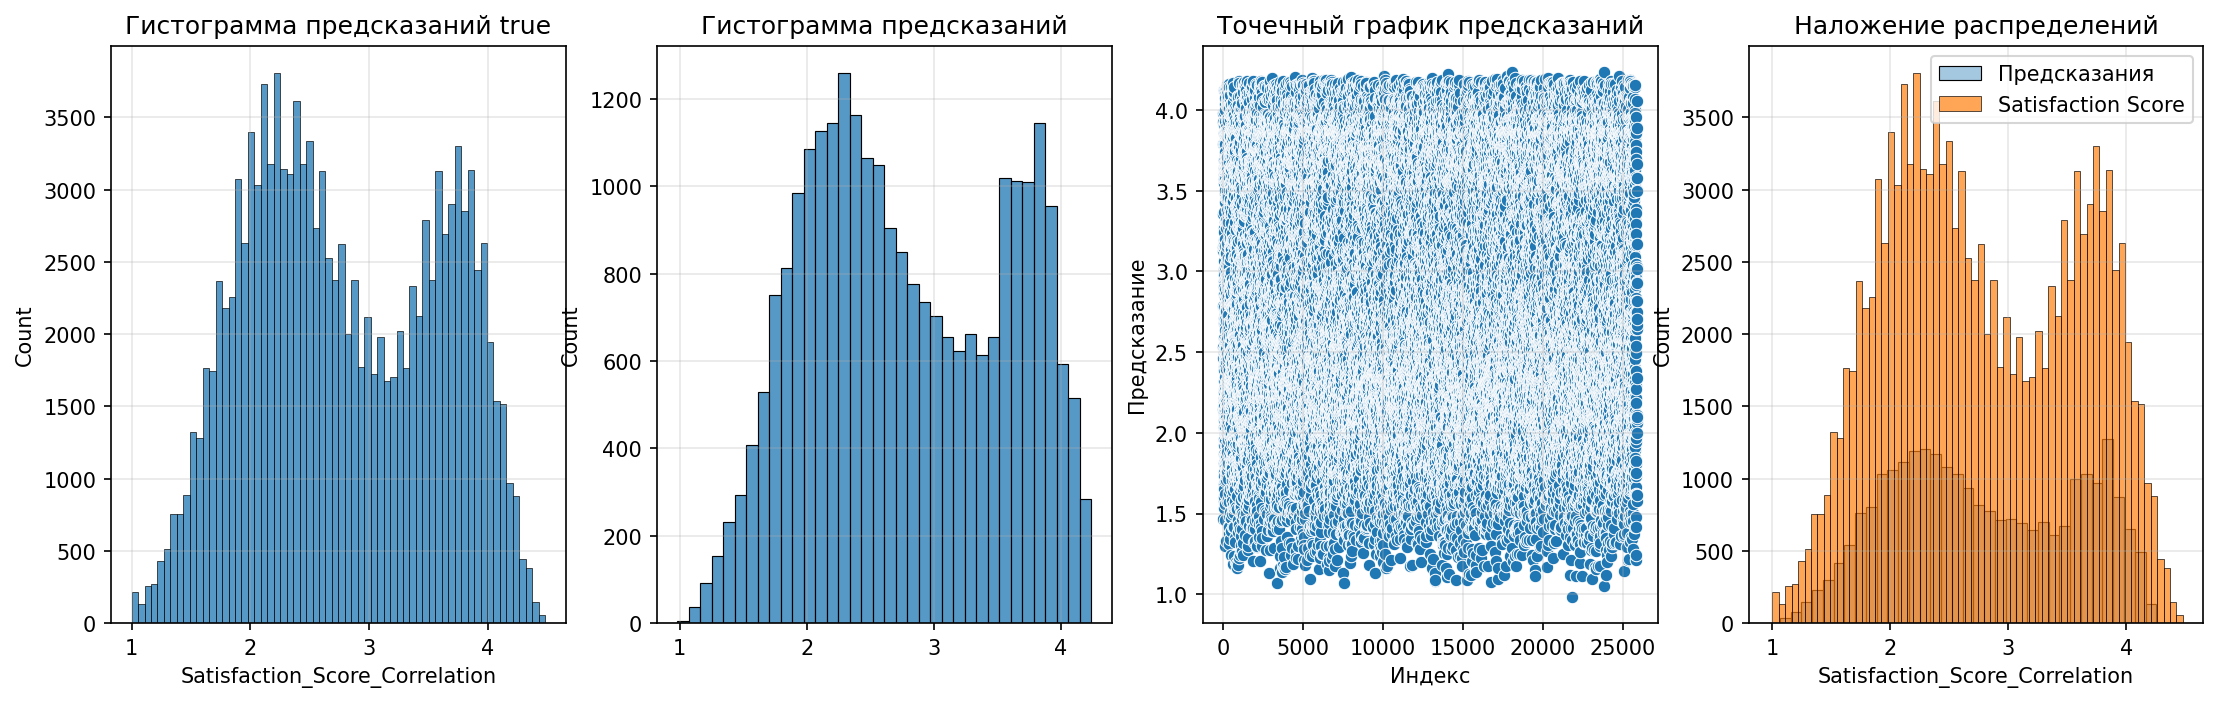

In [73]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)

sns.histplot(df['Satisfaction_Score_Correlation'], ax=axes[0])
axes[0].set_title('Гистограмма предсказаний true')
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_test_xgb, ax=axes[1])
axes[1].set_title('Гистограмма предсказаний')
axes[1].grid(True, alpha=0.3)

sns.scatterplot(x=range(len(y_pred_test_xgb)), y=y_pred_test_xgb, ax=axes[2])
axes[2].set_title('Точечный график предсказаний')
axes[2].set_xlabel('Индекс')
axes[2].set_ylabel('Предсказание')
axes[2].grid(True, alpha=0.3)

sns.histplot(y_pred_cb, label='Предсказания', alpha=0.4, ax=axes[3])
sns.histplot(df['Satisfaction_Score_Correlation'], label='Satisfaction Score', alpha=0.7, ax=axes[3])
axes[3].set_title('Наложение распределений')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

| Модель          | MSE (test)       | MAE (test)       | R² (test)       |
|-----------------|------------------|------------------|-----------------|
| XGB             | 0.03719          | 0.15331          | 0.94165         |
| LightGBM        | 0.03740          | 0.15356          | 0.94133         |
| CatBoost        | 0.03678          | 0.15286          | 0.94230         |
| GradientBoosting| 0.04023          | 0.15879          | 0.93688         |
| RandomForest    | 0.07484          | 0.21042          | 0.88259         |
| LinearRegression| 0.07427          | 0.21446          | 0.88348         |

## Топ-3 модели:

### По MSE :
1. **CatBoost** - 0.03678
2. **XGB** - 0.03719  
3. **LightGBM** - 0.03740

### По MAE :
1. **CatBoost** - 0.15286
2. **XGB** - 0.15331
3. **LightGBM** - 0.15356

### По R2:
1. **CatBoost** - 0.94230
2. **XGB** - 0.94165
3. **LightGBM** - 0.94133